In [1]:
import sys
from pathlib import Path

# Find project root (folder containing 'src')
notebook_dir = Path().resolve()
project_root = notebook_dir
for parent in [notebook_dir] + list(notebook_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"src exists: {(project_root / 'src').exists()}")
print(f"loader exists: {(project_root / 'src' / 'data' / 'loader.py').exists()}")

# Now imports will work
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import get_connection, query

con = get_connection()
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
SAVE = '../outputs/figures/'
print("All imports ready!")

Project root: C:\Users\SUN\qcomm-market-basket-analysis
src exists: True
loader exists: True


IOException: IO Error: Cannot open file "C:\Users\SUN\qcomm-market-basket-analysis\data\processed\instacart.duckdb": The process cannot access the file because it is being used by another process.

File is already open in 
C:\Users\SUN\AppData\Local\Programs\Python\Python313\python.exe (PID 9468)

In [2]:
# Pull orders with 2-15 items — simulating q-comm basket sizes
# We cap at 15 to remove bulk/pantry-stocking outliers
# We remove 1-item baskets — useless for association mining

basket_filter = query("""
    WITH basket_sizes AS (
        SELECT order_id, COUNT(*) AS n_items
        FROM order_products_prior
        GROUP BY order_id
    )
    SELECT order_id
    FROM basket_sizes
    WHERE n_items BETWEEN 2 AND 15
""", con)

print(f"Orders after q-comm filter: {len(basket_filter):,}")
print(f"Removed: {query('SELECT COUNT(DISTINCT order_id) FROM order_products_prior', con).iloc[0,0]:,} - {len(basket_filter):,} orders")

Orders after q-comm filter: 2,436,622
Removed: 3,214,874 - 2,436,622 orders


In [3]:
# Join filtered orders with product names
# We work at DEPARTMENT level first — less sparse, clearer patterns
# Phase 3 will drill down to SKU level within hot departments

print("Building transaction list...")
t0 = time.time()

order_dept = query("""
    SELECT 
        op.order_id,
        d.department
    FROM order_products_prior op
    JOIN products p    USING (product_id)
    JOIN departments d USING (department_id)
    WHERE op.order_id IN (
        SELECT order_id FROM (
            SELECT order_id, COUNT(*) AS n
            FROM order_products_prior
            GROUP BY order_id
        ) WHERE n BETWEEN 2 AND 15
    )
    ORDER BY op.order_id
""", con)

# Group by order_id → list of departments per order
transactions = (
    order_dept
    .groupby('order_id')['department']
    .apply(list)
    .tolist()
)

print(f"Built {len(transactions):,} transactions in {time.time()-t0:.1f}s")
print(f"Example transaction: {transactions[0]}")
print(f"Example transaction: {transactions[100]}")

Building transaction list...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Built 2,436,622 transactions in 211.1s
Example transaction: ['dairy eggs', 'produce', 'pantry', 'pantry', 'pantry', 'produce', 'pantry', 'pantry', 'produce']
Example transaction: ['meat seafood', 'deli', 'produce', 'produce', 'produce', 'produce', 'dry goods pasta', 'dry goods pasta', 'beverages', 'produce']


In [4]:
print("Encoding transactions into boolean matrix...")
t0 = time.time()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded in {time.time()-t0:.1f}s")
print(f"Matrix shape: {df_encoded.shape}")  # (n_orders, n_departments)
print(f"Memory usage: {df_encoded.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Sparsity: {(~df_encoded).sum().sum() / df_encoded.size * 100:.1f}% zeros")
print(f"\nDepartment columns: {list(df_encoded.columns)}")

Encoding transactions into boolean matrix...
Encoded in 5.9s
Matrix shape: (2436622, 21)
Memory usage: 51.2 MB
Sparsity: 80.3% zeros

Department columns: ['alcohol', 'babies', 'bakery', 'beverages', 'breakfast', 'bulk', 'canned goods', 'dairy eggs', 'deli', 'dry goods pasta', 'frozen', 'household', 'international', 'meat seafood', 'missing', 'other', 'pantry', 'personal care', 'pets', 'produce', 'snacks']


In [5]:
print("Running Apriori...")
t_apriori_start = time.time()

frequent_itemsets_apriori = apriori(
    df_encoded,
    min_support=0.01,        # item pair must appear in 1% of orders
    use_colnames=True,       # show department names not column indices
    max_len=3,               # max itemset size = 3 (pairs and triples)
    verbose=0
)

t_apriori = time.time() - t_apriori_start

print(f"Apriori completed in {t_apriori:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets_apriori):,}")
print(f"\nTop 10 by support:")
display(
    frequent_itemsets_apriori
    .sort_values('support', ascending=False)
    .head(10)
)

Running Apriori...
Apriori completed in 5.32 seconds
Frequent itemsets found: 398

Top 10 by support:


,support,itemsets
17,0.730199,frozenset({produce})
6,0.642515,frozenset({dairy eggs})
85,0.494632,"frozenset({dairy eggs, produce})"
3,0.419283,frozenset({beverages})
18,0.379901,frozenset({snacks})
9,0.314933,frozenset({frozen})
14,0.295545,frozenset({pantry})
53,0.282885,"frozenset({beverages, produce})"
129,0.268495,"frozenset({snacks, produce})"
44,0.266330,"frozenset({dairy eggs, beverages})"


In [6]:
print("Running FP-Growth...")
t_fpgrowth_start = time.time()

frequent_itemsets_fp = fpgrowth(
    df_encoded,
    min_support=0.01,
    use_colnames=True,
    max_len=3
)

t_fpgrowth = time.time() - t_fpgrowth_start

print(f"FP-Growth completed in {t_fpgrowth:.2f} seconds")
print(f"Frequent itemsets found: {len(frequent_itemsets_fp):,}")
print(f"\nSpeedup vs Apriori: {t_apriori/t_fpgrowth:.1f}x faster")

Running FP-Growth...
FP-Growth completed in 17.40 seconds
Frequent itemsets found: 398

Speedup vs Apriori: 0.3x faster


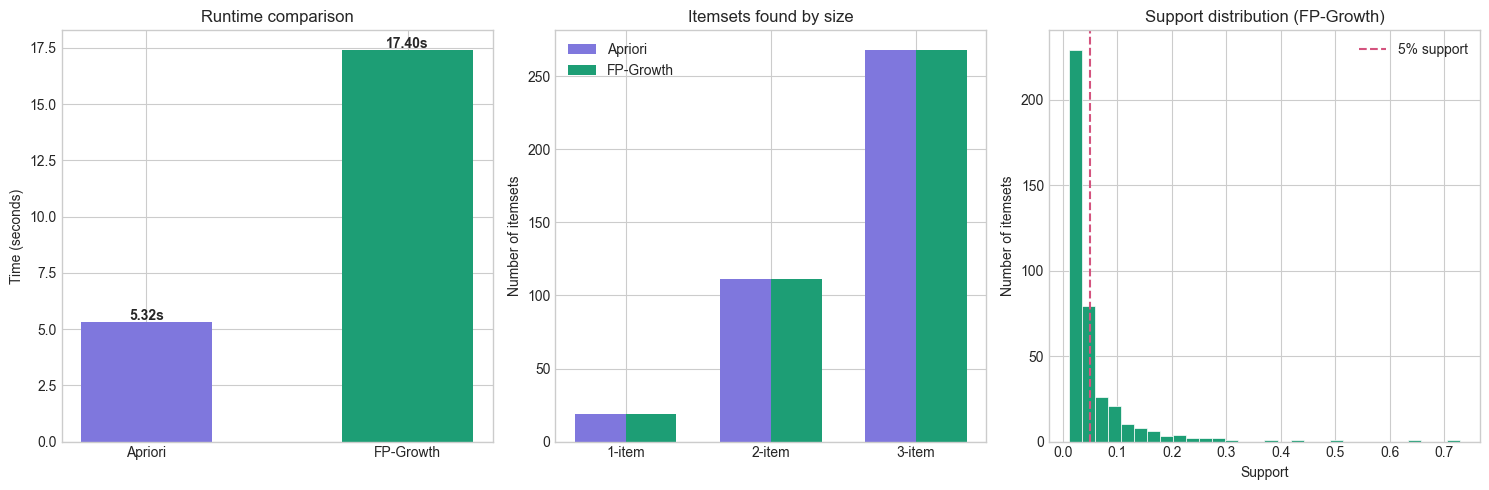

Apriori is 3.3x faster than FP-Growth at department level
Expected: FP-Growth wins at SKU level (sparse, 49K products)
Insight:  FP-Growth tree overhead > savings when data is dense & small


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Runtime comparison
algos   = ['Apriori', 'FP-Growth']
times   = [t_apriori, t_fpgrowth]
colors_ = ['#7F77DD', '#1D9E75']

bars = axes[0].bar(algos, times, color=colors_, width=0.5)
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Runtime comparison')
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{t:.2f}s', ha='center', fontweight='bold')

# Plot 2: Itemsets found by size
size_ap = frequent_itemsets_apriori.copy()
size_ap['size'] = size_ap['itemsets'].apply(len)
size_fp = frequent_itemsets_fp.copy()
size_fp['size'] = size_fp['itemsets'].apply(len)

size_counts_ap = size_ap['size'].value_counts().sort_index()
size_counts_fp = size_fp['size'].value_counts().sort_index()

x = np.arange(len(size_counts_ap))
w = 0.35
axes[1].bar(x - w/2, size_counts_ap.values, w, label='Apriori',  color='#7F77DD')
axes[1].bar(x + w/2, size_counts_fp.values, w, label='FP-Growth', color='#1D9E75')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{i}-item' for i in size_counts_ap.index])
axes[1].set_ylabel('Number of itemsets')
axes[1].set_title('Itemsets found by size')
axes[1].legend()

# Plot 3: Support distribution of frequent itemsets
axes[2].hist(frequent_itemsets_fp['support'], bins=30, color='#1D9E75', 
             edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('Support')
axes[2].set_ylabel('Number of itemsets')
axes[2].set_title('Support distribution (FP-Growth)')
axes[2].axvline(0.05, color='#D4537E', linestyle='--', lw=1.5, label='5% support')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{SAVE}09_algorithm_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
speedup = t_apriori / t_fpgrowth
if speedup >= 1:
    print(f"FP-Growth is {speedup:.1f}x FASTER than Apriori")
else:
    print(f"Apriori is {1/speedup:.1f}x faster than FP-Growth at department level")
    print("Expected: FP-Growth wins at SKU level (sparse, 49K products)")
    print("Insight:  FP-Growth tree overhead > savings when data is dense & small")


In [8]:
# Generate rules from FP-Growth frequent itemsets
rules = association_rules(
    frequent_itemsets_fp,
    metric='lift',
    min_threshold=1.0       # keep all lift > 1 for now, we'll filter later
)

# Add itemset size info
rules['antecedent_len'] = rules['antecedents'].apply(len)
rules['consequent_len'] = rules['consequents'].apply(len)

# Clean up for readability
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f"Total rules generated: {len(rules):,}")
print(f"\nRules summary:")
print(rules[['support','confidence','lift']].describe().round(3))

Total rules generated: 1,584

Rules summary:
        support  confidence      lift
count  1584.000    1584.000  1584.000
mean      0.037       0.258     1.215
std       0.038       0.209     0.171
min       0.010       0.014     1.000
25%       0.015       0.095     1.103
50%       0.024       0.192     1.179
75%       0.043       0.357     1.277
max       0.495       0.857     2.353


In [9]:
# Apply production-quality filters
rules_filtered = rules[
    (rules['support']    >= 0.01) &   # appears in 1%+ of orders
    (rules['confidence'] >= 0.30) &   # 30%+ conditional probability
    (rules['lift']       >= 1.5)      # 50% more likely than baseline
].copy()

rules_filtered = rules_filtered.sort_values('lift', ascending=False)

print(f"Rules after filtering: {len(rules_filtered):,}")
print(f"\nTop 20 rules by lift:")
display(
    rules_filtered[['antecedents_str', 'consequents_str', 
                     'support', 'confidence', 'lift']]
    .head(20)
    .round(3)
)

Rules after filtering: 5

Top 20 rules by lift:


,antecedents_str,consequents_str,support,confidence,lift
717,"beverages, personal care",household,0.013,0.302,2.353
1555,"dry goods pasta, pantry",canned goods,0.016,0.311,1.936
1453,"deli, dry goods pasta",bakery,0.011,0.343,1.529
1301,international,"pantry, produce",0.017,0.341,1.519
264,"deli, meat seafood",bakery,0.011,0.339,1.510


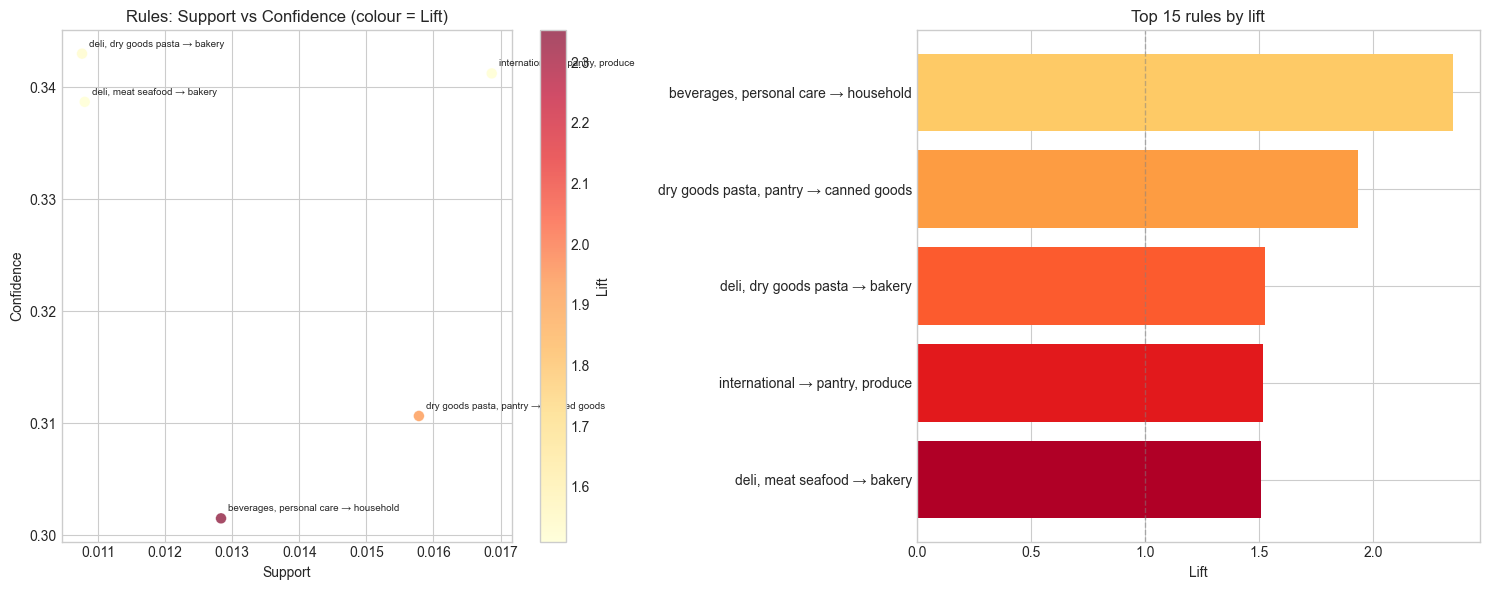

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: support vs confidence, coloured by lift
sc = axes[0].scatter(
    rules_filtered['support'],
    rules_filtered['confidence'],
    c=rules_filtered['lift'],
    cmap='YlOrRd',
    s=60,
    alpha=0.7,
    edgecolors='white',
    linewidths=0.3
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Rules: Support vs Confidence (colour = Lift)')

# Annotate top 5 rules
top5 = rules_filtered.nlargest(5, 'lift')
for _, row in top5.iterrows():
    axes[0].annotate(
        f"{row['antecedents_str']} → {row['consequents_str']}",
        (row['support'], row['confidence']),
        fontsize=7, ha='left',
        xytext=(5, 5), textcoords='offset points'
    )

# Bar: Top 15 rules by lift
top15 = rules_filtered.head(15)
rule_labels = [
    f"{r['antecedents_str']} → {r['consequents_str']}"
    for _, r in top15.iterrows()
]
colors_lift = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top15)))
axes[1].barh(rule_labels[::-1], top15['lift'][::-1], color=colors_lift[::-1])
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 15 rules by lift')
axes[1].axvline(1.0, color='gray', linestyle='--', lw=1, alpha=0.5)

plt.tight_layout()
plt.savefig(f'{SAVE}10_rules_scatter_and_top.png', dpi=150, bbox_inches='tight')
plt.show()

Total filtered rules: 5
Antecedent lengths: {2: 4, 1: 1}
Consequent lengths: {1: 4, 2: 1}
Single A→B rules: 0
No single rules at lift>=1.5 — relaxing to lift>=1.0 for heatmap...
Rules after relaxing: 168


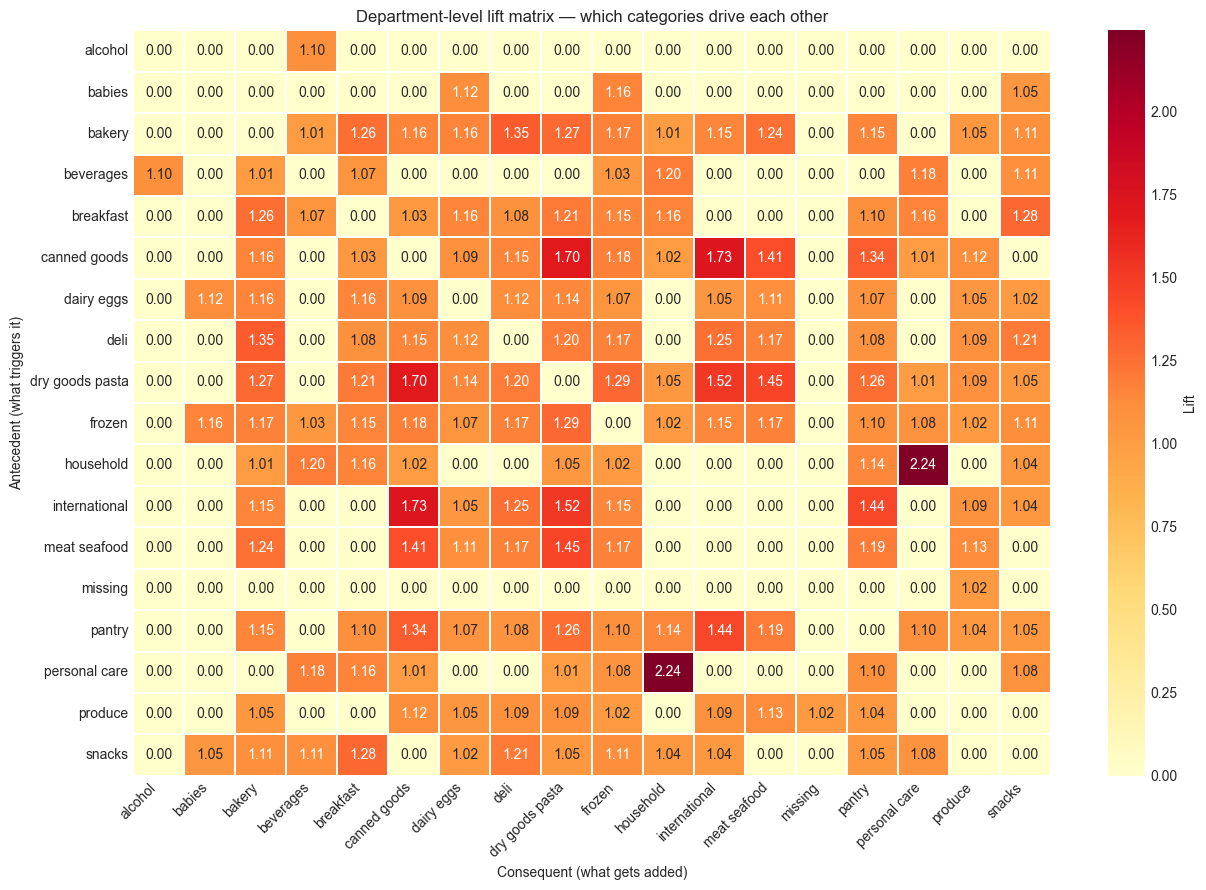

In [11]:
# Diagnose first
print(f"Total filtered rules: {len(rules_filtered)}")
print(f"Antecedent lengths: {rules_filtered['antecedent_len'].value_counts().to_dict()}")
print(f"Consequent lengths: {rules_filtered['consequent_len'].value_counts().to_dict()}")

single_rules = rules_filtered[
    (rules_filtered['antecedent_len'] == 1) &
    (rules_filtered['consequent_len'] == 1)
].copy()

print(f"Single A→B rules: {len(single_rules)}")

# ── If single_rules is empty, relax the lift threshold just for this viz ──
if len(single_rules) == 0:
    print("No single rules at lift>=1.5 — relaxing to lift>=1.0 for heatmap...")
    single_rules = rules[
        (rules['antecedent_len'] == 1) &
        (rules['consequent_len'] == 1) &
        (rules['support'] >= 0.01)
    ].copy()
    single_rules['antecedents_str'] = single_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    single_rules['consequents_str'] = single_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))
    print(f"Rules after relaxing: {len(single_rules)}")

if len(single_rules) == 0:
    print("Still empty — skipping heatmap. Check your min_support in Cell 8.")
else:
    lift_matrix = single_rules.pivot_table(
        index='antecedents_str',
        columns='consequents_str',
        values='lift',
        aggfunc='max'
    ).fillna(0)   # ← fill NaN with 0 so heatmap never gets empty slices

    fig, ax = plt.subplots(figsize=(13, 9))
    sns.heatmap(
        lift_matrix,
        annot=True, fmt='.2f',
        cmap='YlOrRd',
        linewidths=0.3,
        ax=ax,
        cbar_kws={'label': 'Lift'}
    )
    ax.set_title('Department-level lift matrix — which categories drive each other')
    ax.set_xlabel('Consequent (what gets added)')
    ax.set_ylabel('Antecedent (what triggers it)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{SAVE}11_lift_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
# Now drill into SKU level for the top 3 departments by order volume
# This is where real product recommendations come from

top_depts = query("""
    SELECT d.department, COUNT(*) AS cnt
    FROM order_products_prior op
    JOIN products p    USING (product_id)
    JOIN departments d USING (department_id)
    GROUP BY d.department
    ORDER BY cnt DESC
    LIMIT 3
""", con)['department'].tolist()

print(f"Drilling into top departments: {top_depts}")

# Get SKU-level transactions within these departments only
sku_orders = query(f"""
    SELECT op.order_id, p.product_name
    FROM order_products_prior op
    JOIN products p    USING (product_id)
    JOIN departments d USING (department_id)
    WHERE d.department IN ('{"','".join(top_depts)}')
      AND op.order_id IN (
          SELECT order_id FROM (
              SELECT order_id, COUNT(*) AS n
              FROM order_products_prior
              GROUP BY order_id
          ) WHERE n BETWEEN 2 AND 15
      )
    USING SAMPLE 50000  -- sample 50k orders for speed
""", con)

sku_transactions = (
    sku_orders
    .groupby('order_id')['product_name']
    .apply(list)
    .tolist()
)

# Filter to transactions with 2+ items
sku_transactions = [t for t in sku_transactions if len(t) >= 2]
print(f"SKU-level transactions: {len(sku_transactions):,}")

# Encode and run FP-Growth
te2 = TransactionEncoder()
te2_array = te2.fit(sku_transactions).transform(sku_transactions)
df_sku = pd.DataFrame(te2_array, columns=te2.columns_)

fi_sku = fpgrowth(df_sku, min_support=0.005, use_colnames=True, max_len=2)
rules_sku = association_rules(fi_sku, metric='lift', min_threshold=1.5)
rules_sku['antecedents_str'] = rules_sku['antecedents'].apply(lambda x: ', '.join(x))
rules_sku['consequents_str'] = rules_sku['consequents'].apply(lambda x: ', '.join(x))
rules_sku_filtered = rules_sku[rules_sku['confidence'] >= 0.25].sort_values('lift', ascending=False)

print(f"\nTop 20 SKU-level rules:")
display(rules_sku_filtered[['antecedents_str','consequents_str',
                             'support','confidence','lift']].head(20).round(3))

Drilling into top departments: ['produce', 'dairy eggs', 'snacks']
SKU-level transactions: 53

Top 20 SKU-level rules:


,antecedents_str,consequents_str,support,confidence,lift
0,Total Plain Greek Strained Yogurt,Serrano Chile Peppers,0.019,1.0,53.0
1,Serrano Chile Peppers,Total Plain Greek Strained Yogurt,0.019,1.0,53.0
2,Whole Organic Omega 3 Milk,Original Pure Creamy Almond Milk,0.019,1.0,53.0
3,Original Pure Creamy Almond Milk,Whole Organic Omega 3 Milk,0.019,1.0,53.0
6,Organic Popcorn,Organic Whole String Cheese,0.019,1.0,53.0
7,Organic Whole String Cheese,Organic Popcorn,0.019,1.0,53.0
20,Organic Unsalted Butter,Organic Heavy Whipping Cream,0.019,1.0,53.0
18,Grape White/Green Seedless,Blue Cheese Crumbles,0.019,1.0,53.0
19,Blue Cheese Crumbles,Grape White/Green Seedless,0.019,1.0,53.0
13,Total 0% Greek Yogurt,Organic Hot House Tomato,0.019,1.0,53.0


In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save department-level rules
rules_filtered[['antecedents_str','consequents_str',
                'support','confidence','lift',
                'antecedent_len','consequent_len']]\
    .to_csv('../data/processed/rules_department.csv', index=False)

# Save SKU-level rules
rules_sku_filtered[['antecedents_str','consequents_str',
                     'support','confidence','lift']]\
    .to_csv('../data/processed/rules_sku.csv', index=False)

print(f"Saved {len(rules_filtered)} department rules")
print(f"Saved {len(rules_sku_filtered)} SKU rules")
print("\nFiles saved to data/processed/ — input for Phase 3")

Saved 5 department rules
Saved 99 SKU rules

Files saved to data/processed/ — input for Phase 3


In [14]:
print("=" * 55)
print("PHASE 2 SUMMARY — Apriori + FP-Growth")
print("=" * 55)
print(f"Apriori runtime:          {t_apriori:.2f}s")
print(f"FP-Growth runtime:        {t_fpgrowth:.2f}s")
print(f"Speedup:                  {t_apriori/t_fpgrowth:.1f}x")
print(f"Frequent itemsets (dept): {len(frequent_itemsets_fp)}")
print(f"Rules after filtering:    {len(rules_filtered)}")
print(f"SKU-level rules:          {len(rules_sku_filtered)}")
print()
print("Top 5 department rules by lift:")
for _, r in rules_filtered.head(5).iterrows():
    print(f"  {r['antecedents_str']:20} → {r['consequents_str']:20}  lift={r['lift']:.2f}")

con.close()

PHASE 2 SUMMARY — Apriori + FP-Growth
Apriori runtime:          5.32s
FP-Growth runtime:        17.40s
Speedup:                  0.3x
Frequent itemsets (dept): 398
Rules after filtering:    5
SKU-level rules:          99

Top 5 department rules by lift:
  beverages, personal care → household             lift=2.35
  dry goods pasta, pantry → canned goods          lift=1.94
  deli, dry goods pasta → bakery                lift=1.53
  international        → pantry, produce       lift=1.52
  deli, meat seafood   → bakery                lift=1.51
